# orbitalchime.py interactive tutorial

# 1 Getting started

## 1.1 Installing the orbitalchime package

To run this toturial you must have installed the `orbitalchime` package in your python environment. If you have not done so already, you can follow the instructions at the [github repository](https://www.github.com/bryanlougheed/orbitalchime) to install the package to your python environment using the Linux terminal, Windows powershell or equivalent 




## 1.2 Importing packages

After installation, we can import the package into our python session. Here, `orbitalchime` is imported under the `ochime` alias. You could use a different alias if it conflicts with other packages that you have already installed. We will also need `numpy` for handling arrays, and we will also import `matplotlib` so that we can plot some things, as well as the `scipy` signal processing functions. 

In [24]:
import orbitalchime as ochime
import numpy as np
import scipy.signal as sig
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
plt.rcParams["font.family"] = ["Helvetica", "Arial"]
plt.rcParams["font.size"] = 8

# 2 Astronomical parameters

## 2.1 Import astronomical parameters

Below, we can use the `getlaskar2004()` function to import the astronomical parameters from the past 10000 kiloyears (10 million years) from Laskar et al. (2004). This will give us the vectos `tka` (time slice interval in ka before 2000 CE) and its associated vectors `ecc` (*eccentricity* ratio of the orbital ellipse, **e**), `obl` (*obliquity* of the ecliptic, **ε**, in radians) and `lpe`. The latter is *longitude of perihelion*, the solar longitude (orbital angle), in radians, of the tropical year where perihelion occurs. Changes in lpe are a result of changes in *general precession*, i.e. the combined effect of *axial precession* (the orientation of the Earth) and *apsidal precession* (the orientation of the Earth's orbit). Laskar et al. (2004) give longitude of perihelion relative to the northern hemisphere autumn equinox, referred to as $\boldsymbol{\overline{\omega}}$.


In [2]:
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(500, 0))

## 2.2 Plot astronomical parameters

We will visually plot the astronomical parameters from Laskar et al. (2004) to familiarise ourselves with them. When plotting, we will convert radian angles to degree angles for human readability.

Longitude of perihelion ($\boldsymbol{\overline{\omega}}$) is given by Laskar et al. (2004) as the orbital angle relative to northern hemisphere autumn equinox. However, we would like to know the value relative to northern hemisphere spring equinox, i.e. in terms of geocentric solar longitude (**λ**), the the orbital angle relative to northern hemisphere spring equinox. This is useful because the start of the tropical year is typically defined as northern hemipshere spring equinox in climate studies.

For reference, where **λ** is the solar longitude (orbit):<br>
**λ** = 0°: northern hemipshere spring equinox<br>
**λ** = 90°: northern hemisphere summer solstice<br>
**λ** = 180°: nothern hemipshere autumn equinox<br>
**λ** = 270°: northern hemisphere winter solstice

To know the equivalent **λ** value of $\boldsymbol{\overline{\omega}}$, we must adjust by 180°. The current $\boldsymbol{\overline{\omega}}$ value is 102.9°, which means that perihelion occurs when **λ** is 102.9 + 180 = 282.9°. This is in early January, just after the northern hemisphere December winter solstice*. So, for those of you living who experience darkness and cold during January, you can at least take solace in the fact that the Earth is closest to the Sun at that time of the year.

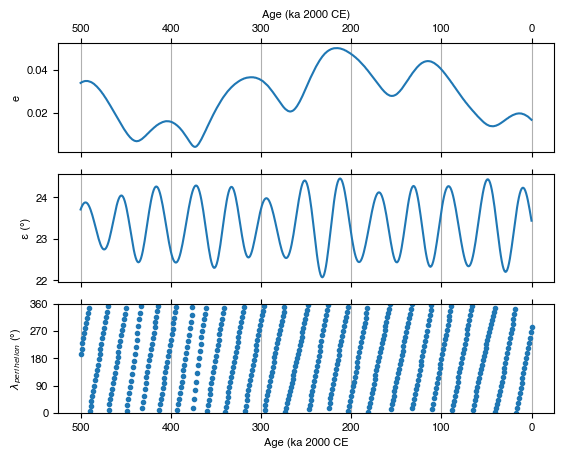

In [3]:
# Plot eccentricity
plt.subplot(3, 1, 1)
plt.plot(tka, ecc, '-')
plt.ylabel('e')
plt.gca().invert_xaxis()
plt.xlabel('Age (ka 2000 CE)')
plt.grid(axis='x') 
plt.gca().xaxis.set_label_position("top") 
plt.tick_params(top=True, bottom=True, labeltop=True, labelbottom=False)

# Plot obliquity
plt.subplot(3, 1, 2)
plt.plot(tka, np.rad2deg(obl), '-') # also convert from radians to degrees
plt.ylabel('ε (°)')
plt.gca().invert_xaxis()
plt.grid(axis='x') 
plt.tick_params(top=True, bottom=True, labeltop=False, labelbottom=False)

# Longitude of perihelion in geocentric solar longitude
plt.subplot(3, 1, 3)
lpegeo = np.rad2deg(lpe) + 180 # change to geocentric solar longitude
lpegeo[lpegeo>=360] -= 360 # ensure 0-360 range by subtracting 360 from values that are >= 360
plt.plot(tka, lpegeo , '.')
plt.ylabel('$\\lambda_{perihelion}$ (°)')
plt.xlabel('Age (ka 2000 CE')
plt.gca().invert_xaxis()
plt.grid(axis='x') 
plt.ylim(0,360)
plt.yticks([0, 90, 180, 270, 360])
plt.tick_params(top=True, bottom=True, labeltop=False, labelbottom=True)

plt.show()

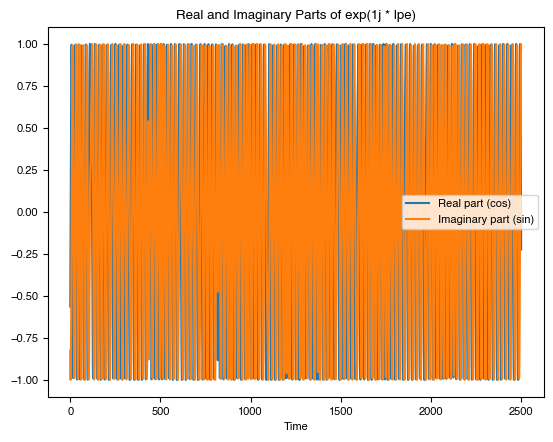

In [14]:
z = np.exp(1j * lpe)

plt.plot(np.real(z), label='Real part (cos)')
plt.plot(np.imag(z), label='Imaginary part (sin)')
plt.legend()
plt.title('Real and Imaginary Parts of exp(1j * lpe)')
plt.xlabel('Time')
plt.show()

## 2.3 **e**⋅sin($\boldsymbol{\overline{\omega}}$)

In the literature, the sine of the $\boldsymbol{\overline{\omega}}$ angle is sometimes plotted instead, i.e. as a waveform (see upper plot below). Palaeoclimatologists sometimes interprete the peaks and troughs of this waveform as *maximum precession* and *minimum precession*. However, care should be taken when using such terms (or they should perhaps be avoided) seeing as there is no minimum or maximum $\boldsymbol{\overline{\omega}}$, as it is simply any given orbital angle between 0° and 360°. Instead of considering peaks and troughs of a sine wave, it may be more intuitve to consider which part of the tropical year coincides with perihelion, i.e. $\lambda_{perihelion}$.

The effect of longitude of perihelion upon Earth's climate is amplified by eccentricity (**e**). In a perfectly circular orbit (**e** = 0), it would be climatically irrelevant where in the orbit perihelion occurs, as both the Earth-Sun distance and the Earth's orbital speed would be the same for all parts of the orbit. In a more elliptical orbit, the distance from the Sun varies throughout the orbit, as does the orbital speed of the Earth (faster when closer to the Sun and vice versa). In such a case, both the intensity and length of the seasons are affected by where in the orbit they occur. To very roughly visualise the combined effects of **e** and $\boldsymbol{\overline{\omega}}$, they are sometimes considered together as one term: **e**⋅sin($\boldsymbol{\overline{\omega}}$), shown in the lower plot below. The  **e**⋅sin($\boldsymbol{\overline{\omega}}$) term is sometimes referred to in the literature as *climatic precession*.

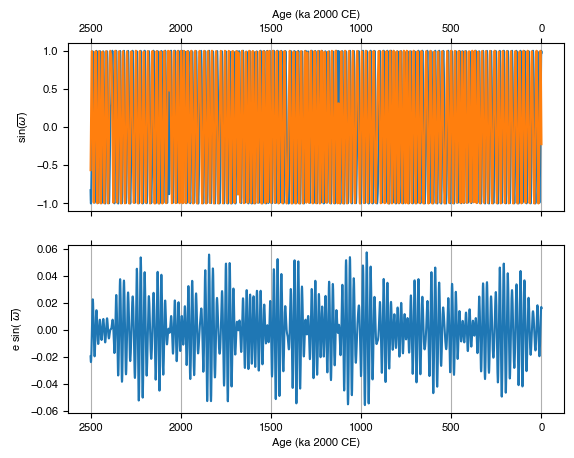

In [13]:
# Sine of omega-bar
plt.subplot(2, 1, 1)
plt.plot(tka, np.sin(lpe), '-')
plt.plot(tka, np.exp(1j * lpe), '-')
plt.ylabel('sin($\\overline{\\omega}$)')
plt.xlabel('Age (ka 2000 CE)')
plt.gca().invert_xaxis()
plt.gca().xaxis.set_label_position("top") 
plt.grid(axis='x') 
plt.tick_params(top=True, bottom=True, labeltop=True, labelbottom=False)

# e*sin(omega-bar) "Climatic precession"
plt.subplot(2, 1, 2)
plt.plot(tka, ecc*np.sin(lpe), '-')
plt.ylabel('e sin( $\\overline{\\omega}$)')
plt.xlabel('Age (ka 2000 CE)')
plt.gca().invert_xaxis()
plt.grid(axis='x') 
plt.tick_params(top=True, bottom=True, labeltop=False, labelbottom=True)

plt.show()

## 2.4 Power spectral density of astronomical parameters

We can also make use of the `scipy` package to create peridograms to look at the power spectral density of the astronomical parameters eccentricity, obliquity and longitude of perihelion. We will do this using the last 20 million years worth of astronomincal paramaeters, in order to have a good sample size to detect low frequency cycles. Note that for other periods of history, the power spectral density of the astronomical parameters might be different. For example, due the Moon slowly receding from the Earth, the mean period of obliquity cycles has been slowly increasing (~39 kyr in the Cretacious to ~41 kyr now).

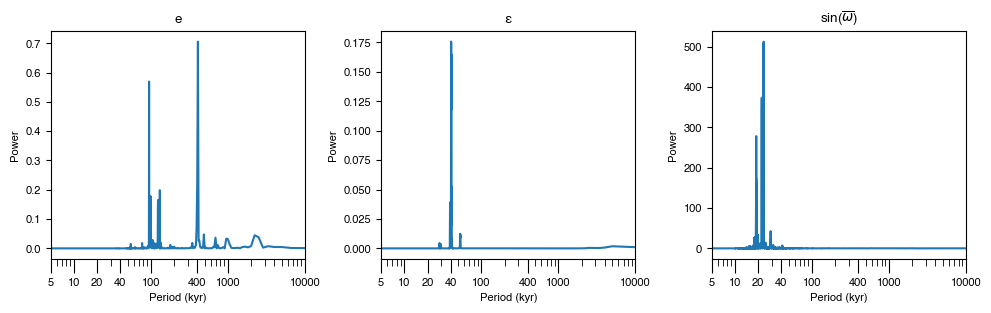

In [5]:
tka, ecc, obl, lpe = ochime.getlaskar2004(option=3, timeslice=(20000, 0))

# compute peridodograms
# here we analyse longitude of perihelion as sin(lpe), because periodograms are best
# suited for analysing waveforms
eccfreq, eccpower = sig.periodogram(ecc, fs=1) # sampling frequency (fs) is 1 kyr
oblfreq, oblpower = sig.periodogram(obl, fs=1) # sampling frequency (fs) is 1 kyr
lpefreq, lpepower = sig.periodogram(np.sin(lpe), fs=1) # sampling frequency (fs) is 1 kyr

# plot periodograms
plt.figure(figsize=(30/2.54, 7.5/2.54)) # 1 inch = 2.54 cm
plt.subplots_adjust(wspace=0.3)

plt.subplot(1,3,1)
plt.plot(1/eccfreq[1:], eccpower[1:]) # 1 / frequency = period
plt.title('e')

plt.subplot(1,3,2)
plt.plot(1/oblfreq[1:], oblpower[1:])
plt.title('ε')
    
plt.subplot(1,3,3)
plt.plot(1/lpefreq[1:], lpepower[1:])
plt.title('sin($\\overline{\\omega}$)')
         
for i in [1,2,3]:
    plt.subplot(1,3,i)
    plt.xlabel('Period (kyr)')
    plt.ylabel('Power')
    plt.xscale('log')
    plt.xlim([5,10000])
    plt.xticks(ticks=[5, 10, 20, 40, 100,400, 1000, 10000], labels=['5','10', '20', '40', '100','400','1000', '10000'])
    plt.tick_params(axis='x', which='major', length=10)
    plt.tick_params(axis='x', which='minor', length=5)

plt.show()


# 3 Daily mean irradiance

## 3.1 Northern hemisphere summer solstice daily mean irradiance

Mean daily top of atmosphere "insolation" in Wm<sup>-2</sup> for various latitudes are commonly analysed in the palaeoclimate literature. Insolation is a scientifically ambiguous term, so we will instead refer to *irradiance* (Wm<sup>-2</sup>). The base unit for energy is the joule (J), and 1 W is equal to 1 Js<sup>-1</sup>. Therefore, irradiance (Wm<sup>-2</sup>) can be thought of as how much energy reaches a one square-metre area per second.

The `dailymeanwm2()` funciton in orbitalchime implements the approach for calculating daily mean irradiance derived by Milanković (1941). We can use the function to calculate the popular *northern hemisphere (NH) summer solstice daily mean irradiance at 65° N latitude*, for the past 0.5 million years, using the Laskar et al. (2004) astronomical parameters that we imported previously. This summer solstice quantity is sometimes reported in the palaeoclimate literautre as "June 21st", but the day of the summer solstice does not always occur on June 21st and can drift by a number of days (from mid June to late June) throughout the millennia due to changes eccentricity and longitude of perihelion.

`dailymeanwm2()` needs to know at what angle, in radians, in the orbit (`sollon`, or **λ**) relative to the northern hemisphere spring equinox it should calculate daily mean irradiance. The northern hemisphere summer solstice occurs at exactly **λ**=90°, i.e. 90° of orbit after the spring equinox. So, we can input the radian value for 90° ($\pi$/2) for `sollon`, or for convenience we can input `np.deg2rad(90)`.

The function also needs to know at what geocentric latitude on Earth we are interested in, so for `lat` we input `np.deg2rad(65)`, i.e. 65° N in radians.

The inputs `ecc`, `obl` and `lpe` are loaded directly from the `getlaskar2004()` function. Here, we will look at the past 500 thousand years.

The input `con` is the solar constant (assumed total solar irradiance at 1 AU distance from the Sun). We will use 1361 Wm<sup>-2</sup>.

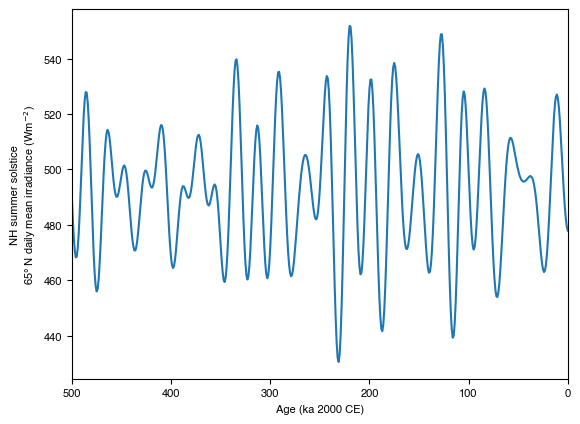

In [6]:
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(500, 0))
irr, dayhrs, rx, tsi = ochime.dailymeanwm2(lat=np.deg2rad(65), sollon=np.deg2rad(90), ecc=ecc, obl=obl, lpe=lpe, con=1361)

# Plot the tka (age in ka) and irradiance
plt.plot(tka, irr)
plt.xlim(500,0)
plt.ylabel('NH summer solstice\n65° N daily mean irradiance (Wm$^{-2}$)')
plt.xlabel('Age (ka 2000 CE)')

plt.show()

The above could be cited as follows: Northern hemisphere summer solstice (λ=90°) daily mean irradiance at 65° N as calculated by *orbitalchime* (Lougheed, in prep.) following Milanković (1941), using the astronomical paramaters of Laskar et al. (2004).

## 3.2 Intra-annual daily mean irradiance

We can also plot an entire tropical year's worth of daily mean irradiance for a particular latitude and period in history. 

### 3.2.1 High latitudes

Here, we will look at the intra-annual irradiance from the last glacial maximum to the start of the Holocene at 65° N, thus covering the period of the last deglaciation.

To look at the intra-annual daily mean irradiance, we first create the vector `dayints` with 0.1 intervals (one tenth of a day) from 0 to 365.2. A daily mean irradiance will be calculated centred on every 0.1 day interval of the year. `dayints` is in the time domain, but `dailymeanwm2` requires `sollon` (**λ**) as input so it knows where in the orbit to calculate the daily mean irradiance. The relationship between time and **λ** is non-linear because the orbital speed of the Earth in its elliptical orbit is not constant. Therefore, we use the function `time2sollon` to convert the day intervals into their associated **λ** using the astronomical parameters of the orbit. `time2sollon` will solve the Kepler equation using an approach described by Moulton (1914).

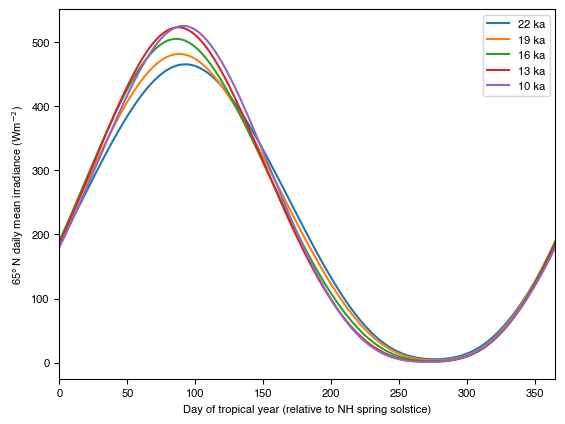

In [7]:
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(25, 0))
dayints = np.arange(0, 365.2, 0.1) # final value will be 365.1. 365.2 = 0.

for i in [22, 19, 16, 13, 10]: # ka to look at
    
    ind = (tka == i)
    
    sollon, eot = ochime.time2sollon(dayints, ecc[ind], lpe[ind], tottime=365.2)
    irr, dayhrs, rx, tsi = ochime.dailymeanwm2(lat=np.deg2rad(65), sollon=sollon, ecc=ecc[ind], obl=obl[ind], lpe=lpe[ind], con=1361)

    plt.plot(dayints, irr, label=str(i)+' ka')
    plt.ylabel('65° N daily mean irradiance (Wm$^{-2}$)')
    plt.xlabel('Day of tropical year (relative to NH spring solstice)')
    plt.legend()

plt.xlim(0,365.2)
plt.show()



The above could be cited as follows: Intra-annual daily (24 hr) mean irradiance at 65° N calculated centred on 0.1 day intervals following Milanković (1941) with the astronomical paramters of Laskar et al. (2004), using *orbitalchime* (Lougheed, in prep.), whereby day intervals were converted to solar longitude by solving the Kepler equation following Moulton (1914).

### 3.2.2 Tropics

We can also repeat the above but for the tropics, e.g., 1° N, this time looking at a number of time intervals around the high-eccentricity Eemian (124 ka, 120 ka, 116 ka, 112 ka, 108 ka). We can also look at the distance of the sun throughout the year, which is also outputted from `dailymeanwm2`. The output demonstrates that, unlike at high latitudes, the intra-annual timing of peak irradiance in the tropics is highly dynamic and sensitive to when in the year perihelion occurs, which can have consequences for seasonal timing in the tropics (e.g., Codron, 2001). This is an important aspect for researchers from high-latitude countries to think about when considering tropical seasonality. Unlike high-latitude regions, the past seasonal timing in the tropics is much less constrained with respect to calendar months.

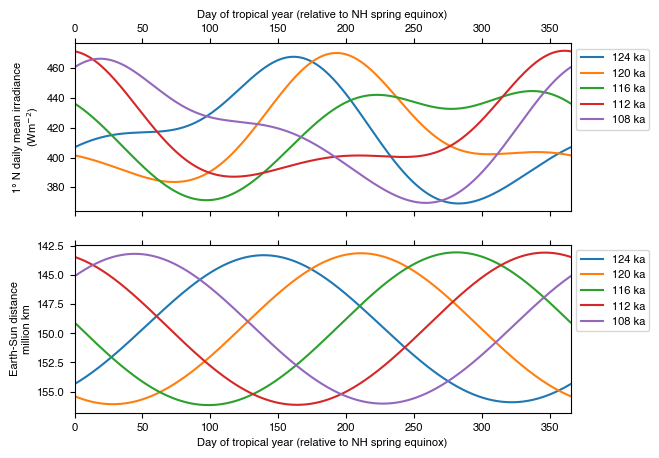

In [8]:
# Import Laskar et al. (2004) astronomical parameters for 125 ka to 105 ka
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(125, 105))
#The latitude that we would like to look at
lat = 1
# The time resolution we would like to plot (0.1 days)
dayints = np.arange(0, 365.2, 0.1) # final value will be 365.1. 365.2 = 0.

latlabel = 'N'
if lat<0:
    latlabel = 'S'
    

for i in [124, 120, 116, 112, 108]: # ka to look at

        ind = (tka == i)
      
        sollon, eot = ochime.time2sollon(dayints, ecc[ind], lpe[ind], tottime=365.2)
        irr, dayhrs, rx, tsi = ochime.dailymeanwm2(lat=np.deg2rad(lat), sollon=sollon, ecc=ecc[ind], obl=obl[ind], lpe=lpe[ind], con=1361)
        rx = rx * 149.598 # convert rx from AU to 10^6 km (1 AU = 149.598 10^6 km)
        
        plt.subplot(2,1,1)
        plt.plot(dayints, irr, label=str(i)+' ka')
        plt.ylabel(str(np.abs(lat))+'° '+latlabel+' daily mean irradiance\n(Wm$^{-2}$)')
        plt.xlabel('Day of tropical year (relative to NH spring equinox)')
        plt.legend(bbox_to_anchor=(1, 1))
        plt.gca().xaxis.set_label_position("top") 
        plt.tick_params(top=True, bottom=True, labeltop=True, labelbottom=False)
        plt.xlim(0,365.2)

        plt.subplot(2,1,2)
        plt.plot(dayints, rx, label=str(i)+' ka')
        plt.ylabel('Earth-Sun distance\nmillion km')
        plt.xlabel('Day of tropical year (relative to NH spring equinox)')
        plt.legend(bbox_to_anchor=(1, 1))
        plt.gca().invert_yaxis()
        plt.tick_params(top=True, bottom=True)
        plt.xlim(0,365.2)

### 3.2.3 All latitudes

We can also create a heatmap for visualising intra-annual daily mean irradiance at all latitudes. To do this efficiently, we will take advantage of the fact that `dailymeanwm2` can operate using vectorised programming (i.e. can accept array input and output corresponding arrays), which allows it to calculate for all latitudes simultaneously. We will calculate for the present day (0 ka). We can see that the peak mean daily irradiance currently occurs in the southern hemisphere, as the southern hemisphere summer solstice occurs close to perihelion. However, the southern hemisphere summer is also slightly shorther in duration than the northern hemisphere summer, as the Earth's orbital speed is also faster at perihelion.

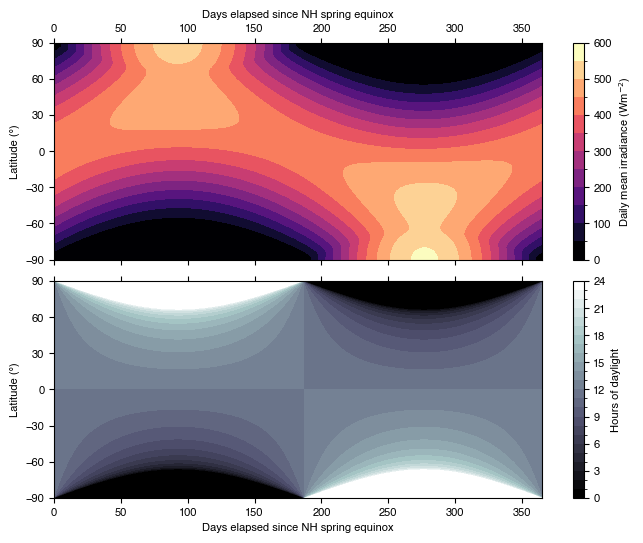

NH astronomical summer duration: 186.4 days
SH astronomical summer duration: 178.8 days


In [9]:
# Import the orbital parameters of 0 ka
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(0))

# Define x-axis intervals for the heatmap (centre of pixel cooordinates)
timeints = np.arange(0.05, 365.2, 0.1)
# Calculate the solar longitudes corresponding to each timeint
sollons, _ = ochime.time2sollon(dayints, ecc, lpe, tottime=365.2)

# Define the y-axis intervals for the heatmap (centre of pixel cooordinates)
lats = np.arange(-89.95, 90, 0.1) # will be changed to radians when put into dailymeanwm2

# Reshape to facilitate vectorised programming in dailymeanwm2
sollons = sollons.reshape(1,-1) # Row vector
lats = lats.reshape(-1,1) # Column vector

# Outputs irr and dayhrs will be a matrix of len(timeints) by len(sollons). Input lats in radians
irr, dayhrs, rx, tsi = ochime.dailymeanwm2(lat=np.deg2rad(lats), sollon=sollons, ecc=ecc, obl=obl, lpe=lpe, con=1361)

# set figure size
plt.figure(figsize=(20/2.54, 15/2.54)) # 1 inch = 2.54 cm
plt.subplots_adjust(hspace=0.1)

## mean daily irradiance subplot
plt.subplot(2,1,1)

# stepwise colours... why so hard
bounds = np.arange(0, 601, 50)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=bounds.size-1)
cmap = plt.get_cmap('magma', bounds.size - 1)

# plot the data
plt.imshow(irr, aspect='auto', extent=[0, 365.2, -90, 90], origin='lower', norm=norm, cmap=cmap)
plt.xlabel('Days elapsed since NH spring equinox')
plt.ylabel('Latitude (°)')
plt.yticks(np.arange(-90, 91, 30))
plt.colorbar(label='Daily mean irradiance (Wm$^{-2}$)')
plt.gca().xaxis.set_label_position("top") 
plt.tick_params(top=True, bottom=True, labeltop=True, labelbottom=False)


## daylight hours subplot
plt.subplot(2,1,2)

# stepwise colours... why so hard
bounds = np.arange(0, 24.1, 1)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=bounds.size-1)
cmap = plt.get_cmap('bone', bounds.size - 1)

# plot the data
plt.imshow(dayhrs, aspect='auto', extent=[0, 365.2, -90, 90], origin='lower', norm=norm, cmap=cmap)
plt.xlabel('Days elapsed since NH spring equinox')
plt.ylabel('Latitude (°)')
plt.yticks(np.arange(-90, 91, 30))
plt.colorbar(label='Hours of daylight')
plt.tick_params(top=True, bottom=True)

plt.show()

# calculate astronomical season length
# get the exact time of the NH autumn / SH spring equinox (lambda = 180 degrees)
# here we use sollon2time (the reverse function of time2sollon)
time, _ = ochime.sollon2time(np.deg2rad(180), ecc, lpe, tottime=365.2422)

# Time elapsed from NH spring equinox to NH autumn equinox
print(f'NH astronomical summer duration: {time[0]:.1f} days')
# Time elapsed from SH spring equinox to SH autumn equinox
print(f'SH astronomical summer duration: {365.2422 - time[0]:.1f} days')


# 4 Intraday irradiance

Thus far we have computed irradiance (Wm<sup>-2</sup>) based on daily means. It is also possible to use the `orbitalchime` function `intradaywm2` to calculate the intraday irradiance at a time resolution of, e.g., one minute. We will do this for the present day (0 ka before 2000 CE). Amongst other things, `intradaywm2` takes into account the equation of time, the fact that mean solar day hours (what our clocks are based on) are not in synch with local apparent solar hours (what a sundial would show). The latter drifts slightly ahead or behind the former throughout the year. This effect is caused by eccentricity and obliquity and there is a very accessible [Vsauce video](https://www.youtube.com/watch?v=IJhgZBn-LHg) about it.

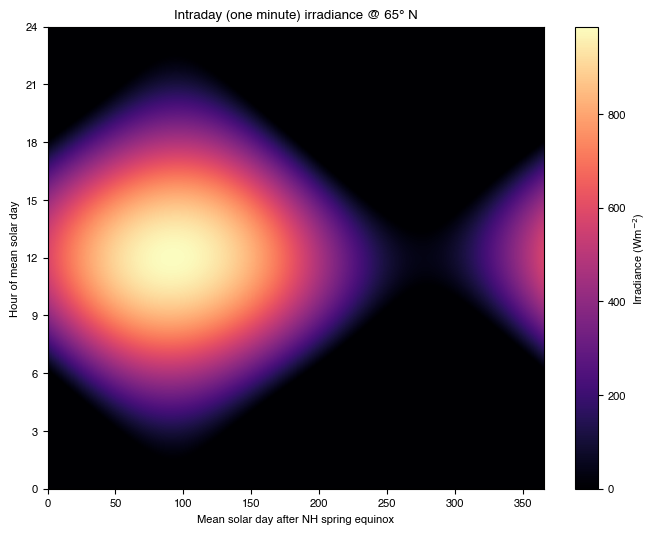

In [10]:
# Get 0 ka Laskar et al. data
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(0))

# latitude to do
lat = 65

# create time vector containing a year's worth of mean solar day intervals 
# time resolution of one minute, in mean solar days
msdint = np.arange(0,365.24219*24*60,1)/24/60 # this way avoids rounding errors

# get the intraday irradiance vector associated with vector msdint
irr, elev, msdhr, lashr, eot = ochime.intradaywm2(lat=np.deg2rad(lat), ecc=ecc, obl=obl, lpe=lpe, dayint=msdint, daysinyear=365.24219, con=1361.0)

# we can make a heatmap showing daily intraday irradiance for the entire year
# We will use 365 days (essentially discard the .24219 day for visualisation purposes)
hmap = irr[msdint<365]
# now reshape the vector to a matrix where rows correspond to a day's worth of irr, and cols to each day
# order = 'F' means we populate by column (the numpy default is by row)
hmap = hmap.reshape(msdint[msdint<1].size, 365, order='F')

latlabel = 'N'
if lat < 0:
    latlabel = 'S'

plt.figure(figsize=(8, 6))
plt.imshow(hmap, extent=[0,365,0,24], aspect='auto', cmap='magma', origin='lower')
plt.colorbar(label='Irradiance (Wm$^{-2}$)')
plt.title('Intraday (one minute) irradiance @ '+str(np.abs(lat))+'° '+latlabel)
plt.xlabel('Mean solar day after NH spring equinox')
plt.ylabel('Hour of mean solar day')
plt.yticks(np.arange(0, 25, 3))

plt.show()



# 5 Quantification of seasonal energy





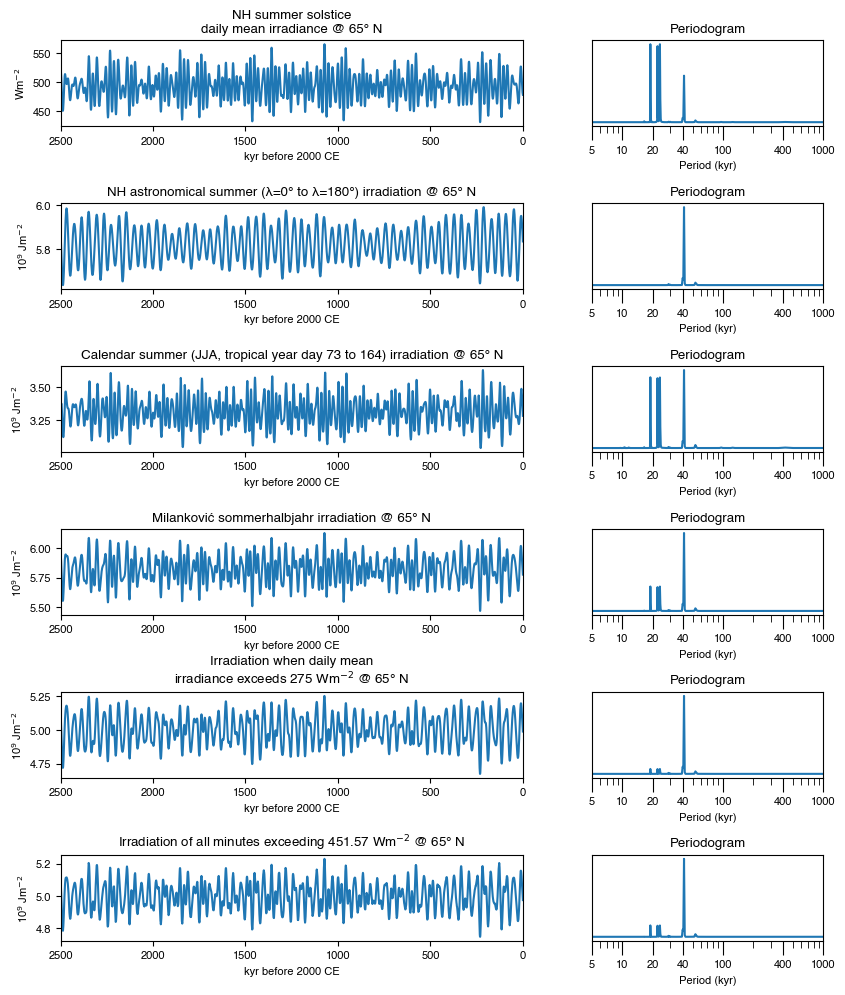

4998975396.776193
4998956747.046165


In [11]:
# lets look at the past 2.5 million years
tkafrom = 2500
tkato = 0
tka, ecc, obl, lpe = ochime.getlaskar2004(option=1, timeslice=(tkafrom, tkato))

# latitude to look at
lattodo = np.deg2rad(65)

# make lists to store subplot data
xdata = []
ydata = []
titles = []
ylabels = []

#----- NH solar solstice mean daily irradiance   
ssirr, _, _, _ = ochime.dailymeanwm2(lat=lattodo, sollon=np.deg2rad(90), ecc=ecc, obl=obl, lpe=lpe, con=1361)
xdata.append(tka)
ydata.append(ssirr)
titles.append('NH summer solstice\ndaily mean irradiance @ 65° N')
ylabels.append('Wm$^{-2}$')
# also do periodogram
ssirrfreq, ssirrpower = sig.periodogram(ssirr, fs=1)
xdata.append(1/ssirrfreq[1:])
ydata.append(ssirrpower[1:])
titles.append('Periodogram')
ylabels.append('')

#----- Astrononomical summer (spring equinox to autumn equinox)
lambdajm2, day1, day2 = ochime.lambdatolambda(lat=lattodo, lambda1=0, lambda2=np.deg2rad(180), ecc=ecc, obl=obl, lpe=lpe, dayres=0.1, totdays=365.2, con=1361, earthshape='sphere')
xdata.append(tka)
ydata.append(lambdajm2/10**9)
titles.append('NH astronomical summer (λ=0° to λ=180°) irradiation @ 65° N')
ylabels.append('10$^{9}$ Jm$^{-2}$')
# also do periodogram
lambdajm2freq, lambdajm2power = sig.periodogram(lambdajm2, fs=1)
xdata.append(1/lambdajm2freq[1:])
ydata.append(lambdajm2power[1:])
titles.append('Periodogram')
ylabels.append('')

#----- Human calendar summer (June, July, August, day 73 to day 164)
daysjm2, lambda1, lambda2 = ochime.daytoday(lat=lattodo, day1=73, day2=164, ecc=ecc, obl=obl, lpe=lpe, dayres=0.1, totdays=365.2, con=1361, earthshape='sphere')
xdata.append(tka)
ydata.append(daysjm2/10**9)
titles.append('Calendar summer (JJA, tropical year day 73 to 164) irradiation @ 65° N')
ylabels.append('10$^{9}$ Jm$^{-2}$')
# also do periodogram
daysjm2freq, daysjm2power = sig.periodogram(daysjm2, fs=1)
xdata.append(1/daysjm2freq[1:])
ydata.append(daysjm2power[1:])
titles.append('Periodogram')
ylabels.append('')
 
#----- Milanković sommerhalbjahr
miljm2 = ochime.sommerhalbjahr(lat=lattodo, ecc=ecc, obl=obl, lpe=lpe, con=1361, timeres=0.1, tottime=365.2, earthshape='sphere')
xdata.append(tka)
ydata.append(miljm2/10**9)
titles.append('Milanković sommerhalbjahr irradiation @ 65° N')
ylabels.append('10$^{9}$ Jm$^{-2}$')
# also do periodogram
miljm2freq, miljm2power = sig.periodogram(miljm2, fs=1)
xdata.append(1/miljm2freq[1:])
ydata.append(miljm2power[1:])
titles.append('Periodogram')
ylabels.append('')

#----- Huybers threshold
thresh = 275 # The threshold used by Huybers
intirr, ndays = ochime.thresholdjm2(thresh=thresh, lat=lattodo, ecc=ecc, obl=obl, lpe=lpe, timeres=0.01, tottime=365.2, con=1361)
xdata.append(tka)
ydata.append(intirr/10**9)
titles.append('Irradiation when daily mean\nirradiance exceeds '+str(thresh)+' Wm$^{-2}$ @ 65° N')
ylabels.append('10$^{9}$ Jm$^{-2}$')
# also do periodogram
intirrfreq, intirrpower = sig.periodogram(intirr, fs=1)
xdata.append(1/intirrfreq[1:])
ydata.append(intirrpower[1:])
titles.append('Periodogram')
ylabels.append('')

#----- Intraday threshold
idjm2 = np.full(ecc.shape, np.nan)
idthresh = 451.57
#msdint = np.arange(0,365.24219*24*60,1)/24/60
msdint = np.arange(0,365.24219,0.01)
# looped
idjm2 = np.full(tka.shape, np.nan)
for i in np.arange(tka.size):
    irr, _, _, _, _ = ochime.intradaywm2(lat=np.deg2rad(lat), ecc=ecc[i], obl=obl[i], lpe=lpe[i], dayint=msdint, daysinyear=365.24219, con=1361.0)
    idjm2[i] = np.mean(irr[irr>=idthresh]) * (np.sum(irr>idthresh)/msdint.size)*(365.24219*86400)
# vectorised (wrong result, needs to be fixed
# irr, _, _, _, _ = ochime.intradaywm2(lat=np.deg2rad(lat), ecc=ecc, obl=obl, lpe=lpe, dayint=msdint, daysinyear=365.24219, con=1361.0)
# idjm2 = np.mean(irr[irr>idthresh], axis=0) * (np.sum(irr>idthresh, axis=0)/msdint.size) / 365.242190419*86400
xdata.append(tka)
ydata.append(idjm2/10**9)
titles.append('Irradiation of all minutes exceeding '+str(idthresh)+' Wm$^{-2}$ @ 65° N')
ylabels.append('10$^{9}$ Jm$^{-2}$')
# also do periodogram
idjm2freq, idjm2power = sig.periodogram(idjm2, fs=1)
xdata.append(1/idjm2freq[1:])
ydata.append(idjm2power[1:])
titles.append('Periodogram')
ylabels.append('')


# make a figure
fig = plt.figure(figsize=(25/2.54, 29.7/2.54))
# define the subplot grid
numrows = 6
numcols = 2
gs = gridspec.GridSpec(numrows, numcols, width_ratios=[6, 3], wspace=0.2, hspace=0.9)

# plot subplots
z = -1
for row in range(numrows):
    for col in range(numcols):
        z = z+1
        ax = fig.add_subplot(gs[row, col])
        ax.plot(xdata[z],ydata[z])
        ax.set_ylabel(ylabels[z])
        ax.set_title(titles[z])
        if z % 2 == 0:
            ax.set_xlabel('kyr before 2000 CE')
            ax.set_xlim(tkafrom, tkato)
        else:
            ax.set_xlabel('Period (kyr)')
            plt.xscale('log')
            plt.xlim([5,1000])
            plt.xticks(ticks=[5, 10, 20, 40, 100,400, 1000], labels=['5','10', '20', '40', '100','400','1000'])
            plt.tick_params(axis='x', which='major', length=10)
            plt.tick_params(axis='x', which='minor', length=5)
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)

plt.show()


print(np.mean(intirr))
print(np.mean(idjm2))
